In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
from tabnanny import verbose

In [3]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#383838',
    'figure.edgecolor': '#383838',
    'axes.facecolor':   '#383838',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

In [4]:
def simulated_response(tau_IIR, A):

    
    fs = 2.4e9 # AWG sampling rate (2.4 GSa/s like the paper)
    dt = 1 / fs
    t_start = 0e-9  # can start time earlier to see flatline at start - but code would need modifications
    t_end = 30e-9  # end time at 200 ns
    t = np.arange(t_start, t_end, dt)

    # 1. Heaviside step function (ideal step)
    u = np.heaviside(t, 1)

    # 2. Add finite rise time (system bandwidth limit)
    # On-chip response parameters from paper (table S1)
    kernel = np.exp(-t / tau_IIR)
    kernel /= kernel.sum()  # normalize
    s = np.convolve((1+A)*kernel, u)[:len(t)]

    # 3. Add noise 
    noise = 0.002 * np.random.randn(len(t))
    s += noise 

    # 4. Clip negative values to zero (step response triggering at time=0)
    s[t<0] = 0 # this step is really for when t_start < 0


    return t, u, s
    


def LS(A, u, s, Ma, Mb):


    N = len(s) # number of time-step measurements, which is the no. of output samples to fit

    u_scaled = (1 + A) * u

    # build the convolution matrix from s 
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            if i >= 0:
                S[n, mb] = s[i]  
        for ma in range(Ma):
            i = n - ma
            if i >= 0:
                S[n, Mb + ma] = u[n - i]


    h_inv = np.linalg.lstsq(S, u_scaled, rcond=None)[0]


    b = h_inv[:Ma]
    a = -h_inv[Ma:]

    return a, b



def corrected_response(s, u, a, b): 
    
    # predict the response using the fitted coefficients
    feedforward = np.convolve(b, s)[:len(s)]
    feedback = np.convolve(a, u)[:len(s)]
    s_corr = feedforward - feedback # negative sign for 'a' coefficients

    return s_corr



def res_sum(t, A, s_corr):

    scaled_u = (1 + A) * np.heaviside(t, 1)
    residuals = scaled_u - s_corr

    return residuals, scaled_u



def delay_time(s_corr, t, A, verbose = False):

    # a useful thing to find is the delay of the corrected response
    # by which I mean the time between 0ns and when the predicted response reaches the required amplitude

    threshold = 0.99 * (1 + A)
    pos = np.where(s_corr >= threshold)[0] # get the first value position where the predicted response reaches 99% of final value

    if len(pos) == 0:
        if verbose:
            print(f"Threshold {threshold:.3f} not reached. Max amplitude was {s_corr.max():.3f}.")
        return None
    else:
        delay = t[pos[0]]
        return delay

Residual sum: 2.886579864025407e-15
Feedback coefficients:  [-4.00000000e-01  4.57966998e-16  1.38777878e-17 -6.93889390e-17
  6.93889390e-17]
Feedforward coefficients:  [-3.27841499e-15  4.19109192e-15 -1.49880108e-15 -2.67147415e-16
  1.35308431e-16]
Delay of corrected response: 0.00 ns


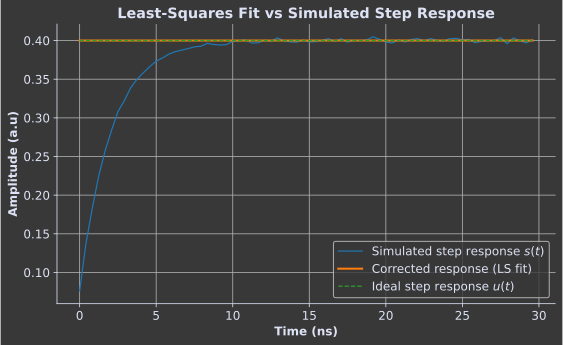

In [5]:
if __name__ == "__main__":

    # parameters taken from table (S1) of the Cryoscope paper
    tau_IIR = 2e-9 # IIR time constant
    A = -0.6 # negative amplitude coefficient s.t 0 < (1 + A) < 1
    Ma = 5 # the number of feedback coefficients in the IIR filter
    Mb = 5 # the number of feedforward coefficients in the IIR filter

    t, u, s = simulated_response(tau_IIR, A)
    a, b = LS(A, u, s, Ma, Mb)
    s_corr = corrected_response(s, u, a, b)
    residuals, delayed_u = res_sum(t, A, s_corr)
    delay = delay_time(s_corr, t, A, verbose = False) #- broken with noise??

    print("Residual sum:", residuals.sum())  # the residuals should sum to as close to zero

    print("Feedback coefficients: ", a)
    print("Feedforward coefficients: ", b)

    if delay is not None:
        print(f"Delay of corrected response: {delay*1e9:.2f} ns")
    else:
        print("Delay could not be computed (threshold not reached).")
    

    # Plotting the results
    mpl.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(8,5))

    ax.plot(t*1e9, s, label="Simulated step response $s(t)$", color="tab:blue", lw=1.2)
    ax.plot(t*1e9, s_corr, label="Corrected response (LS fit)", color="tab:orange", lw=2.0)
    ax.plot(t*1e9, delayed_u, label="Ideal step response $u(t)$", color="tab:green", lw=1.2, ls='--')
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Amplitude (a.u)")
    ax.set_title("Least-Squares Fit vs Simulated Step Response")
    ax.legend()
    ax.grid()

    plt.tight_layout()
    plt.show()



In [6]:
# finding the optimum parameters

if __name__ == "__main__":

    # parameters taken from table (S1) of the Cryoscope paper
    tau_IIR = 2e-9 # IIR time constant
    A = -0.6 # negative amplitude coefficient s.t 0 < (1 + A) < 1
    res_sums = []
    for i in range(10):
        for j in range(10):
            Ma = i + 1 # the number of feedback coefficients in the IIR filter
            Mb = j + 1 # the number of feedforward coefficients in the IIR filter

            t, u, s = simulated_response(tau_IIR, A)
            a, b = LS(A, u, s, Ma, Mb)
            s_corr = corrected_response(s, u, a, b)
            residuals, delayed_u = res_sum(t, A, s_corr)

            delay = delay_time(s_corr, t, A, verbose = False) # broken with noise??

            if delay is not None:
                #print(f"Ma: {Ma}, Mb: {Mb} => Residual sum: {np.linalg.norm(residuals):.9f}") # doesn't work as intended
                res_sums.append((Ma, Mb, residuals.sum()))

    # find the minimum residual sum
    min_abs_res = min(abs(x[2]) for x in res_sums)

    tol = 1e-9  # numerical tolerance for floating-point comparisons
    minima = [x for x in res_sums if abs(abs(x[2]) - min_abs_res) < tol]

    print(f"Minimum |residual sum| = {min_abs_res:.6e}")
    print("Achieved for:")

    for Ma, Mb, res in minima:
        print(f"  Ma={Ma}, Mb={Mb}, residual sum={res:.6e}")

    # lowest amount of filters needed to achieve minimum residual sum
    best = min(minima, key=lambda x: x[0] + x[1])
    print(f"Smallest filter: Ma={best[0]}, Mb={best[1]}")


Minimum |residual sum| = 2.164935e-15
Achieved for:
  Ma=1, Mb=1, residual sum=5.218048e-15
  Ma=2, Mb=2, residual sum=-3.941292e-15
  Ma=3, Mb=3, residual sum=-6.605827e-15
  Ma=4, Mb=4, residual sum=-1.998401e-14
  Ma=5, Mb=5, residual sum=-2.725598e-14
  Ma=6, Mb=6, residual sum=-2.164935e-15
  Ma=7, Mb=7, residual sum=3.647083e-14
  Ma=8, Mb=8, residual sum=2.314815e-13
  Ma=9, Mb=9, residual sum=1.543210e-14
  Ma=10, Mb=10, residual sum=2.314815e-14
Smallest filter: Ma=1, Mb=1
